
Loading TRAIN from: datazerodce\revTrain
  ➤ Loading class: 20_speed_limit
  ➤ Loading class: 60_speed_limit
  ➤ Loading class: bike_lane
  ➤ Loading class: children_crossing
  ➤ Loading class: do_not_enter
  ➤ Loading class: pedestrian_crossing
  ➤ Loading class: stop

Loading TEST from: datazerodce\Test
  ➤ Loading class: 20_speed_limit
  ➤ Loading class: 60_speed_limit
  ➤ Loading class: bike_lane
  ➤ Loading class: children_crossing
  ➤ Loading class: do_not_enter
  ➤ Loading class: pedestrian_crossing
  ➤ Loading class: stop

Loading VAL from: datazerodce\Val
  ➤ Loading class: 20_speed_limit
  ➤ Loading class: 60_speed_limit
  ➤ Loading class: bike_lane
  ➤ Loading class: children_crossing
  ➤ Loading class: do_not_enter
  ➤ Loading class: pedestrian_crossing
  ➤ Loading class: stop

========== DATASET SUMMARY ==========
Train: 4366 images
Val:   1456 images
Test:  1456 images
Class weights: {0: 2.970068027210884, 1: 0.5376847290640394, 2: 2.31005291005291, 3: 1.0208089782557868

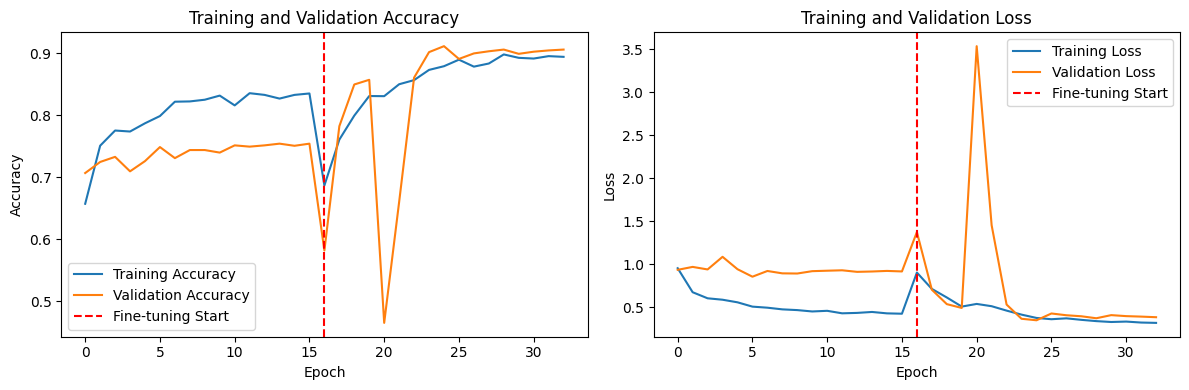

In [1]:
import numpy as np
import cv2
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

class SevenClassDataset:
    def __init__(self, data_path):
        self.data_path = Path(data_path)
        self.classes = [
            '20_speed_limit', '60_speed_limit', 'bike_lane',
            'children_crossing', 'do_not_enter',
            'pedestrian_crossing', 'stop'
        ]
        self.num_classes = len(self.classes)

    def load_dataset(self):
        splits = {
            'train': 'revTrain',
            'test': 'Test',
            'val': 'Val'
        }

        images = {'train': [], 'val': [], 'test': []}
        labels = {'train': [], 'val': [], 'test': []}

        for split_key, folder_name in splits.items():
            split_path = self.data_path / folder_name
            print(f"\nLoading {split_key.upper()} from: {split_path}")

            if not split_path.exists():
                print(f"⚠ Warning: Folder does NOT exist: {split_path}")
                continue

            for class_id, class_name in enumerate(self.classes):
                class_path = split_path / class_name

                if not class_path.exists():
                    print(f" Missing class folder: {class_path}")
                    continue

                print(f"  ➤ Loading class: {class_name}")

                for img_file in class_path.glob("*.*"):
                    img = cv2.imread(str(img_file))
                    if img is not None:
                        img = cv2.resize(img, (128, 128))  # ✅ Changed to 128x128
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                        images[split_key].append(img)
                        labels[split_key].append(class_id)

        for split in images:
            if images[split]:
                images[split] = np.array(images[split])
                labels[split] = np.array(labels[split])
            else:
                images[split] = np.array([])
                labels[split] = np.array([])

        return images, labels

def create_data_augmentation():
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])

dataset = SevenClassDataset('datazerodce')
images, labels = dataset.load_dataset()

print("\n========== DATASET SUMMARY ==========")
print(f"Train: {len(images['train'])} images")
print(f"Val:   {len(images['val'])} images")
print(f"Test:  {len(images['test'])} images")

def preprocess_split(imgs, lbls, num_classes):
    if len(imgs) == 0:
        return imgs, lbls
        
    imgs = imgs.astype("float32")
    imgs = tf.keras.applications.resnet50.preprocess_input(imgs)

    lbls = tf.keras.utils.to_categorical(lbls, num_classes)
    return imgs, lbls

X_train, y_train = preprocess_split(images['train'], labels['train'], dataset.num_classes)
X_val,   y_val   = preprocess_split(images['val'],   labels['val'],   dataset.num_classes)
X_test,  y_test  = preprocess_split(images['test'],  labels['test'],  dataset.num_classes)

# Compute class weights only if we have training data
if len(labels['train']) > 0:
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels['train']),
        y=labels['train']
    )
    class_weights = {i: w for i, w in enumerate(class_weights)}
    print("Class weights:", class_weights)
else:
    class_weights = None
    print("No training data found!")

from tensorflow.keras.applications import ResNet50

def create_resnet_model(num_classes):

    base = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(128, 128, 3)  
    )

    base.trainable = False

    inputs = tf.keras.Input((128, 128, 3))
    
    data_augmentation = create_data_augmentation()
    x = data_augmentation(inputs)
    
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)  # Reduced from 256 to save memory
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)  # Reduced from 0.5
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

if len(X_train) > 0:
    model, base_model = create_resnet_model(dataset.num_classes)
    model.summary()

    callbacks_phase1 = [
        tf.keras.callbacks.ModelCheckpoint(
            "phase1_baseResNet_ZERODCE.h5", 
            save_best_only=True, 
            monitor="val_accuracy",
            save_weights_only=True
        ),
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.2)
    ]

    print("\n=== PHASE 1: Training with frozen base ===")
    
    batch_size_phase1 = 16  # Reduced from 32
    
    history1 = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=batch_size_phase1,  # Smaller batch
        class_weight=class_weights,
        callbacks=callbacks_phase1,
        verbose=1
    )

    callbacks_phase2 = [
        tf.keras.callbacks.ModelCheckpoint(
            "phase2_fineTunedResNet_ZERODCE.h5",
            save_best_only=True,
            monitor="val_accuracy",
            save_weights_only=True
        ),
        tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.2)
    ]

    print("\n=== PHASE 2: Fine-tuning ===")
    base_model.trainable = True

    fine_tune_at = 100
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    batch_size_phase2 = 8  
    
    history2 = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=batch_size_phase2,
        class_weight=class_weights,
        callbacks=callbacks_phase2,
        verbose=1
    )

    model.load_weights("phase2_fineTunedResNet_ZERODCE.h5")
    
    if len(X_test) > 0:
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"\nFINAL TEST ACCURACY: {test_acc:.4f}")
    else:
        print("\n⚠ No test data available for evaluation")
        
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history1.history['accuracy'] + history2.history['accuracy'], label='Training Accuracy')
    plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'], label='Validation Accuracy')
    plt.axvline(len(history1.history['accuracy']), color='red', linestyle='--', label='Fine-tuning Start')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(history1.history['loss'] + history2.history['loss'], label='Training Loss')
    plt.plot(history1.history['val_loss'] + history2.history['val_loss'], label='Validation Loss')
    plt.axvline(len(history1.history['loss']), color='red', linestyle='--', label='Fine-tuning Start')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("No training data available!")

Loaded model weights successfully!

FINAL TEST ACCURACY: 0.9210

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

     20_speed_limit       0.93      0.89      0.91       208
     60_speed_limit       0.91      0.93      0.92       208
          bike_lane       1.00      1.00      1.00       208
  children_crossing       0.82      1.00      0.90       208
       do_not_enter       0.99      0.86      0.92       208
pedestrian_crossing       1.00      0.77      0.87       208
               stop       0.85      0.99      0.92       208

           accuracy                           0.92      1456
          macro avg       0.93      0.92      0.92      1456
       weighted avg       0.93      0.92      0.92      1456



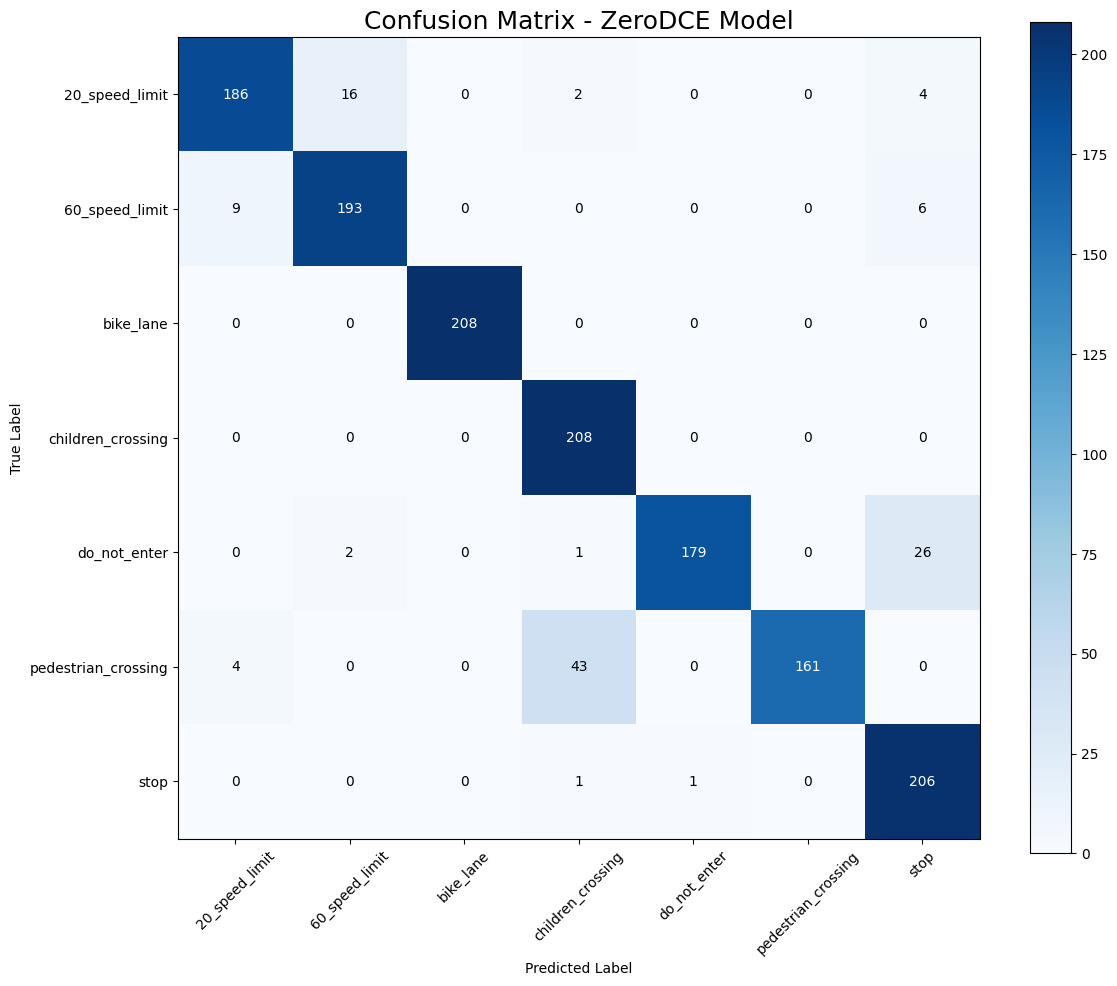

✅ Saved complete model for UI: baseresnet_zerodce_complete.h5


In [3]:
import numpy as np
import cv2
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

class SevenClassDataset:
    def __init__(self, data_path):
        self.data_path = Path(data_path)
        self.classes = [
            '20_speed_limit', '60_speed_limit', 'bike_lane',
            'children_crossing', 'do_not_enter',
            'pedestrian_crossing', 'stop'
        ]
        self.num_classes = len(self.classes)

    def load_dataset(self):
        splits = {'train': 'revTrain', 'test': 'Test', 'val': 'Val'}

        images = {'train': [], 'val': [], 'test': []}
        labels = {'train': [], 'val': [], 'test': []}

        for split_key, folder_name in splits.items():
            split_path = self.data_path / folder_name

            for class_id, class_name in enumerate(self.classes):
                class_path = split_path / class_name
                if not class_path.exists():
                    continue

                for img_file in class_path.glob("*.*"):
                    img = cv2.imread(str(img_file))
                    if img is not None:
                        img = cv2.resize(img, (128, 128))
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                        images[split_key].append(img)
                        labels[split_key].append(class_id)

        for split in images:
            images[split] = np.array(images[split])
            labels[split] = np.array(labels[split])

        return images, labels


def preprocess_split(imgs, lbls, num_classes):
    imgs = imgs.astype("float32")
    imgs = tf.keras.applications.resnet50.preprocess_input(imgs)
    lbls = tf.keras.utils.to_categorical(lbls, num_classes)
    return imgs, lbls

from tensorflow.keras.applications import ResNet50

def create_resnet_model(num_classes):

    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(128, 128, 3)
    )

    base_model.trainable = True
    fine_tune_at = 100
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = tf.keras.Input((128, 128, 3))

    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])

    x = data_augmentation(inputs)
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


dataset = SevenClassDataset("datazerodce")  
images, labels = dataset.load_dataset()

X_test, y_test = preprocess_split(
    images['test'], labels['test'], dataset.num_classes
)


model = create_resnet_model(dataset.num_classes)
model.load_weights("baseresnet_zerodce.h5")  
print("Loaded model weights successfully!")


if len(X_test) > 0:
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nFINAL TEST ACCURACY: {test_acc:.4f}")

    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    print("\n======================================")
    print("CLASSIFICATION REPORT")
    print("======================================")
    print(classification_report(
        y_true_classes, 
        y_pred_classes, 
        target_names=dataset.classes
    ))


    cm = confusion_matrix(y_true_classes, y_pred_classes)

    plt.figure(figsize=(12, 10))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix - ZeroDCE Model', fontsize=18)
    plt.colorbar()

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.xticks(np.arange(len(dataset.classes)), dataset.classes, rotation=45)
    plt.yticks(np.arange(len(dataset.classes)), dataset.classes)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig("confusion_matrix_zerodce.png", dpi=300)
    plt.show()

    model.save("baseresnet_zerodce_complete.h5", include_optimizer=False)
    print("Saved complete model for UI: baseresnet_zerodce_complete.h5")

else:
    print("\nNo test data found!")